In [1]:
%matplotlib inline

In [2]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

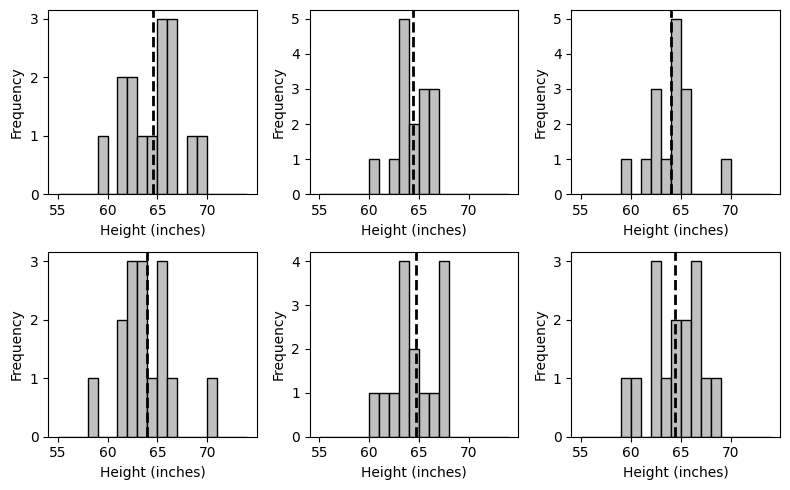

In [3]:
fig,ax = plt.subplots(2,3,figsize=(8,5))

for i in range(2):
    for j in range(3):
        x = stats.norm.rvs(loc=64.5, scale=2.5, size=15)
        ax[i,j].hist(x, bins=np.arange(55,75,1),edgecolor='black', color='silver')
        ax[i,j].axvline(np.mean(x), color='k', linestyle='dashed', linewidth=2)
        ax[i,j].set_xlabel('Height (inches)')
        ax[i,j].set_ylabel('Frequency')
fig.tight_layout()

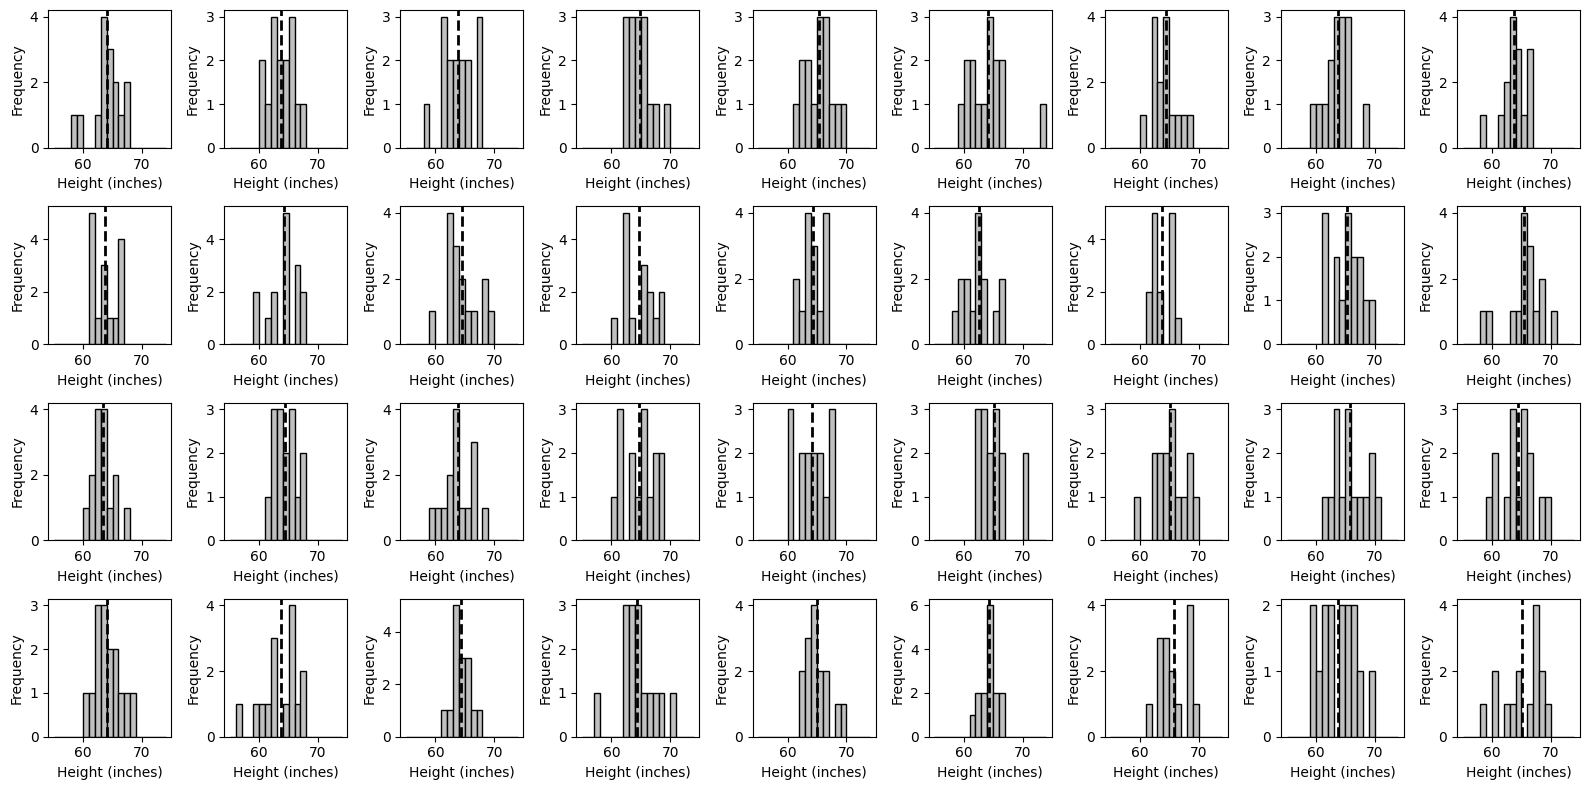

In [4]:
fig,ax = plt.subplots(4,9,figsize=(16,8))

mean_list = []
for i in range(4):
    for j in range(9):
        x = stats.norm.rvs(loc=64.5, scale=2.5, size=15)
        ax[i,j].hist(x, bins=np.arange(55,75,1),edgecolor='black', color='silver')
        ax[i,j].axvline(np.mean(x), color='k', linestyle='dashed', linewidth=2)
        mean_list.append(np.mean(x))
        ax[i,j].set_xlabel('Height (inches)')
        ax[i,j].set_ylabel('Frequency')
fig.tight_layout()

Text(0, 0.5, 'Frequency')

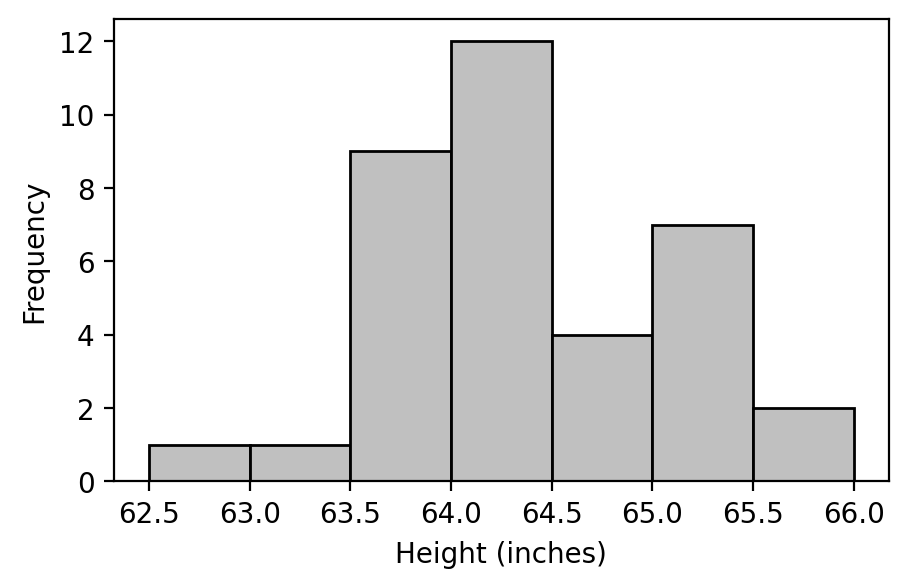

In [5]:
plt.figure(figsize=[5,3],dpi=200)
plt.hist(mean_list, bins=np.arange(62.5,66.5,0.5), edgecolor='black', color='silver')
plt.xlabel('Height (inches)')
plt.ylabel('Frequency')


In [6]:
np.mean(mean_list),np.std(mean_list),np.percentile(mean_list, 2.5),np.percentile(mean_list, 97.5)

(np.float64(64.38237542812605),
 np.float64(0.7023507420238074),
 np.float64(63.23244953396524),
 np.float64(65.77288256737944))

In [7]:
# Generate 50 random heights from N(mean=64.5, sd=2.5)
heights = stats.norm.rvs(loc=64.5, scale=2.5, size=50)


# Bootstraping

In [8]:
from scipy.stats import bootstrap

# SciPy's bootstrap requires data as a tuple of arrays
result = bootstrap((heights,), np.median, n_resamples=100)
print("Bootstrap median estimate:", result.bootstrap_distribution.mean())
print("95% CI:", result.confidence_interval)


Bootstrap median estimate: 64.81276289806682
95% CI: ConfidenceInterval(low=np.float64(63.301525288860844), high=np.float64(65.27395955379342))


In [9]:
# SciPy's bootstrap requires data as a tuple of arrays
result = bootstrap((heights,), np.median, n_resamples=200)
print("Bootstrap median estimate:", result.bootstrap_distribution.mean())
print("95% CI:", result.confidence_interval)

Bootstrap median estimate: 64.71549128691743
95% CI: ConfidenceInterval(low=np.float64(63.50527716192755), high=np.float64(65.46424028977233))


In [ ]:
n = 50
nboots = 100

# Preallocate array to hold bootstrap medians
res = []

for i in range(nboots):
    # Sample with replacement from 'heights'
    bootdata = np.random.choice(heights, size=n, replace=True)
    res.append(np.median(bootdata))

res = np.array(res)
print("The 95% confidence interval for the median height is: [{:.2f}, {:.2f}]".format(np.percentile(res, 2.5), np.percentile(res, 97.5)))

The 95% confidence interval for the median height is: [63.55, 65.36]


In [11]:
n = 50
nboots = 1000

# Preallocate array to hold bootstrap medians
res = []

for i in range(nboots):
    # Sample with replacement from 'heights'
    bootdata = np.random.choice(heights, size=n, replace=True)
    res.append(np.median(bootdata))

res = np.array(res)
print("The 95% confidence interval for the median height is: [{:.2f}, {:.2f}]".format(np.percentile(res, 2.5), np.percentile(res, 97.5)))

The 95% confidence interval for the median height is: [63.45, 65.44]


# Parametric bootstrap

In [12]:
duration_data = [1.02, 1.20, 0.49, 0.27, 0.05, 1.15, 0.92, 0.98, 0.04, 0.23, 0.46, 0.56, 0.05, 0.48, 1.27]

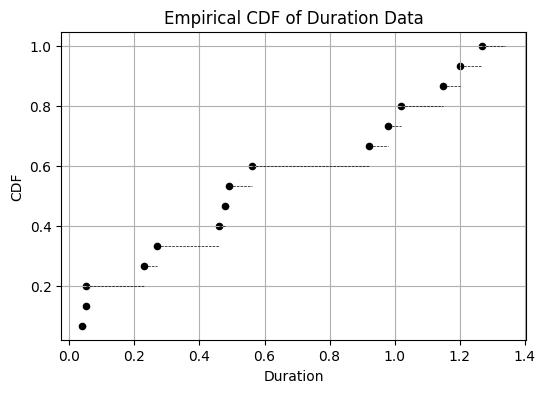

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Sort the data
x = np.sort(duration_data)
x_plot = np.concatenate([x,[x[-1]+(x[-1]-x[-2])]])  # Add an extra point for plotting

# Compute empirical CDF values
y = np.arange(1, len(x)+1) / len(x)

# Plot
plt.figure(figsize=(6,4))
# plotting function
plt.scatter(x,y,marker='o', color='k', s=20)
for i,x0 in enumerate(x):
    plt.plot([x0,x_plot[i+1]],[y[i],y[i]],color='k', lw=0.5, ls='--')

plt.xlabel("Duration")
plt.ylabel("CDF")
plt.title("Empirical CDF of Duration Data")
plt.grid(True)
plt.show()

In [ ]:
# cdf_fit = expon.cdf(x_sorted, loc=loc, scale=scale)


Fitted λ (rate) = 1.6358
Fitted mean = 0.6113


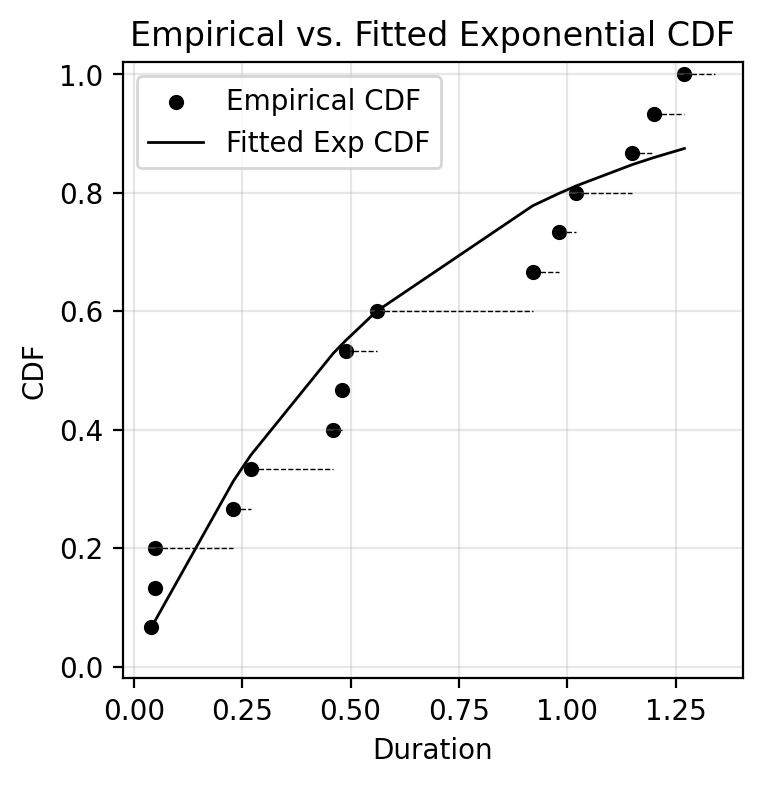

In [14]:
from scipy.stats import expon

data = np.array(duration_data)

# --- Fit exponential distribution ---
# Constrain location to 0 if you know times are nonnegative and start at 0
loc_fixed = 0.0
loc, scale = expon.fit(data, floc=loc_fixed)   # scale = 1/lambda
lambda_hat = 1.0 / scale

print(f"Fitted λ (rate) = {lambda_hat:.4f}")
print(f"Fitted mean = {scale:.4f}")

ecdf_x = np.sort(data)
ecdf_y = np.arange(1, len(data)+1) / len(data)
cdf_fit = expon.cdf(ecdf_x, loc=loc, scale=scale)

plt.figure(figsize=(4,4),dpi=200)
# Horizontal-only ECDF (no vertical jumps)
plt.scatter(x,y,marker='o', color='k', s=20, label='Empirical CDF')
for i,x0 in enumerate(x):
    plt.plot([x0,x_plot[i+1]],[y[i],y[i]],color='k', lw=0.5, ls='--')

plt.plot(ecdf_x, cdf_fit, 'k-', lw=1, label='Fitted Exp CDF')
plt.xlabel("Duration")
plt.ylabel("CDF")
plt.title("Empirical vs. Fitted Exponential CDF")
plt.ylim(-0.02, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [15]:
from scipy import stats
stats.expon.ppf(0.9,scale=scale)

np.float64(1.407647020183693)

In [ ]:
def exp_quart_par_boot(x, nboots, random_state=None):
    """
    Bootstrap the 90th percentile of an exponential fitted by mean,
    and return the sample standard deviation of those percentiles.

    Parameters
    ----------
    x : array-like
        Data (assumed nonnegative).
    nboots : int
        Number of bootstrap resamples.
    random_state : int or None
        Optional RNG seed for reproducibility.

    Returns
    -------
    float
        Sample standard deviation (ddof=1) of bootstrap 90th percentiles.
    """
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    n = x.size

    qval = np.empty(nboots, dtype=float)
    for i in range(nboots):
        pbx = rng.choice(x, size=n, replace=True)  # bootstrap sample
        pbmean = pbx.mean()                        # exponential scale = mean
        qval[i] = stats.expon.ppf(0.90, scale=pbmean)   # qexp(0.90, rate=1/pbmean) -> scale=pbmean

    return np.std(qval, ddof=1),qval

In [18]:
sd_,qvals =exp_quart_par_boot(duration_data, nboots=1000, random_state=42)
print("The standard deviation of the bootstrap 90th percentile is:", sd_)

The standard deviation of the bootstrap 90th percentile is: 0.26091283214452604


# Jackknife

In [ ]:
def jackknife_durs_one_by_one(x):
    """
    For each leave-one-out sample, fit Exp by mean (scale = mean)
    Compute the 90th percentile for that sample
    Return the range (min, max) of these percentiles
    Print the full-data value as in R
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    qval = np.empty(n)

    for i in range(n):
        pbx = np.delete(x, i)           # leave-one-out sample
        pbmean = pbx.mean()             # exponential scale = mean
        qval[i] = expon.ppf(0.90, scale=pbmean)  # qexp(0.90, rate=1/pbmean)
    y = (qval.min(), qval.max())
    # Full dataset value: qexp(0.9, rate = 1/mean(x)) -> scale = mean(x)
    full_val = expon.ppf(0.90, scale=x.mean())
    print(f"Full dataset value = {full_val}")
    return y

In [22]:
# Example call
rng_minmax = jackknife_durs_one_by_one(duration_data)
print("Range of jackknife 90th percentiles:", rng_minmax)

Full dataset value = 1.407647020183693
Range of jackknife 90th percentiles: (np.float64(1.2993158739037827), np.float64(1.5016144213596883))


# Permutation example

In [27]:
import numpy as np

group_training = np.array([92, 95, 88, 90, 93, 96, 91, 94])
group_control  = np.array([86, 82, 85, 84, 83, 87, 80, 88])

obs_diff = group_training.mean() - group_control.mean()
print("Observed difference:", obs_diff)

combined = np.concatenate([group_training, group_control])
nA = len(group_training)
nperm = 10000

perm_diffs = np.empty(nperm)

for i in range(nperm):
    shuffled = np.random.permutation(combined)
    permA = shuffled[:nA]
    permB = shuffled[nA:]
    perm_diffs[i] = permA.mean() - permB.mean()

p_value = np.mean(perm_diffs >= obs_diff)
print("Permutation p-value:", p_value)

Observed difference: 8.0
Permutation p-value: 0.0003
